# 1. Introduction

This notebook implements a **Deepfake Detection System** that classifies images as **Real** or **Fake** (AI-generated).

Multiple deep learning architectures are trained and compared:

| # | Model | Description |
|---|-------|-------------|
| 1 | **VGG16 + MTCNN** | Transfer learning with VGG16 backbone and MTCNN face extraction |
| 2 | **CNN** | Custom CNN built from scratch |
| 3 | **LSTM** | Recurrent model on reshaped image sequences |
| 4 | **CNN + LSTM** | Hybrid convolutional-recurrent architecture |
| 5 | **InceptionV3** | Transfer learning with InceptionV3 and partial fine-tuning |
| 6 | **InceptionV3 + Attention** | InceptionV3 enhanced with an attention mechanism |

All models are evaluated using **accuracy**, **confusion matrices**, and **classification reports** to determine the best approach for deepfake detection.



# 2. Imports & Setup

All required libraries are imported here. Make sure you have them installed:

```bash
pip install tensorflow mtcnn opencv-python scikit-learn matplotlib numpy pandas
```

In [1]:
# Core libraries
import tensorflow as tf
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# MTCNN for face detection
from mtcnn import MTCNN

# Scikit-learn utilities
from sklearn.utils import shuffle
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Keras layers and models
from tensorflow.keras.applications import VGG16, InceptionV3
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, BatchNormalization,
    Conv2D, MaxPooling2D, LSTM, Reshape, Input,
    GlobalAveragePooling2D, Multiply
)
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.optimizers import Adam

print("All imports successful")
print(f"TensorFlow version: {tf.__version__}")

All imports successful
TensorFlow version: 2.16.2


# 3. Dataset Configuration

The dataset is organized into training and testing sets, each containing **real** and **fake** face images.

```
archive/
├── real_and_fake_face/
│   ├── training_real/    ← Real face images (train)
│   └── training_fake/    ← Fake/AI-generated images (train)
└── test_dataset/
    ├── real/             ← Real face images (test/validation)
    └── fake/             ← Fake/AI-generated images (test/validation)
```

**Labels:** Real = 0, Fake = 1

In [2]:
# ── Dataset paths (adapted for local VSCode execution) ──
# CHANGED: Replaced Google Colab Drive paths with local BASE_PATH
BASE_PATH = "/Users/mayankpandey/Downloads/Epics/project1/archive"

TRAIN_REAL = os.path.join(BASE_PATH, "real_and_fake_face", "training_real")
TRAIN_FAKE = os.path.join(BASE_PATH, "real_and_fake_face", "training_fake")

TEST_REAL = os.path.join(BASE_PATH, "test_dataset", "real")
TEST_FAKE = os.path.join(BASE_PATH, "test_dataset", "fake")

# Image configuration (unchanged from original)
IMG_SIZE = 224
EPOCHS = 10
BATCH_SIZE = 32

# Verify dataset paths exist
for path_name, path_val in [("TRAIN_REAL", TRAIN_REAL), ("TRAIN_FAKE", TRAIN_FAKE),
                             ("TEST_REAL", TEST_REAL), ("TEST_FAKE", TEST_FAKE)]:
    exists = os.path.exists(path_val)
    status = "" if exists else "❌"
    print(f"{status} {path_name}: {path_val}")

 TRAIN_REAL: /Users/mayankpandey/Downloads/Epics/project1/archive/real_and_fake_face/training_real
 TRAIN_FAKE: /Users/mayankpandey/Downloads/Epics/project1/archive/real_and_fake_face/training_fake
 TEST_REAL: /Users/mayankpandey/Downloads/Epics/project1/archive/test_dataset/real
 TEST_FAKE: /Users/mayankpandey/Downloads/Epics/project1/archive/test_dataset/fake


# 4. Data Preprocessing

### MTCNN Face Extraction

Before feeding images to the models, we use **MTCNN (Multi-task Cascaded Convolutional Networks)** to detect and extract face regions from each image.

This helps the models focus on facial features rather than background noise, improving classification accuracy.

**Pipeline:**
1. Read image using OpenCV
2. Detect faces using MTCNN
3. Crop the face region (or use full image if no face detected)
4. Resize to `224 × 224` pixels
5. Normalize pixel values to `[0, 1]`

In [3]:
# Initialize MTCNN face detector
print("Initializing MTCNN face detector...")
detector = MTCNN()
print("MTCNN detector ready")

Initializing MTCNN face detector...


2026-03-27 00:38:40.267953: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-27 00:38:40.268010: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-27 00:38:40.268016: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-27 00:38:40.268064: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-27 00:38:40.268109: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


MTCNN detector ready


In [4]:
def extract_face(img):
    """Extract face region from an image using MTCNN.
    
    If a face is detected, returns the cropped face region.
    If no face is detected (or an error occurs), returns the original image.
    """
    try:
        faces = detector.detect_faces(img)

        if faces:
            x, y, w, h = faces[0]['box']

            x = max(0, x)
            y = max(0, y)

            face = img[y:y+h, x:x+w]

            if face is not None and face.size != 0:
                return face

    except:
        pass

    return img

# 5. Data Loading

The `load_data()` function reads images from the specified directories, applies MTCNN face extraction, resizes to `224×224`, and normalizes pixel values.

**Labels:**
- Real images → label `0`
- Fake images → label `1`

In [5]:
def load_data(real_dir, fake_dir):
    """Load and preprocess images from real and fake directories.
    
    Returns:
        images: numpy array of shape (N, 224, 224, 3), normalized to [0, 1]
        labels: numpy array of shape (N,), where 0=Real, 1=Fake
    """
    images = []
    labels = []

    for f in os.listdir(real_dir):
        path = os.path.join(real_dir, f)
        img = cv2.imread(path)

        if img is None:
            continue

        try:
            img = extract_face(img)
        except:
            continue

        if img is None or img.size == 0:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(0)  # Real

    for f in os.listdir(fake_dir):
        path = os.path.join(fake_dir, f)
        img = cv2.imread(path)

        if img is None:
            continue

        try:
            img = extract_face(img)
        except:
            continue

        if img is None or img.size == 0:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        images.append(img)
        labels.append(1)  # Fake

    return np.array(images)/255.0, np.array(labels)

In [6]:
# Load and preprocess the dataset
print("Loading dataset...")
print("Preprocessing images with MTCNN face extraction...")

X_train, y_train = load_data(TRAIN_REAL, TRAIN_FAKE)
X_test, y_test = load_data(TEST_REAL, TEST_FAKE)

# Shuffle training data
X_train, y_train = shuffle(X_train, y_train)

print("\nDataset loaded successfully!")
print(f"   Train shape: {X_train.shape}")
print(f"   Test shape:  {X_test.shape}")
print(f"   Train labels: {len(y_train)} (Real: {(y_train==0).sum()}, Fake: {(y_train==1).sum()})")
print(f"   Test labels:  {len(y_test)} (Real: {(y_test==0).sum()}, Fake: {(y_test==1).sum()})")

Loading dataset...
Preprocessing images with MTCNN face extraction...

Dataset loaded successfully!
   Train shape: (2041, 224, 224, 3)
   Test shape:  (396, 224, 224, 3)
   Train labels: 2041 (Real: 1081, Fake: 960)
   Test labels:  396 (Real: 209, Fake: 187)


---
### Helper Function: Training Visualization
Reusable function for plotting accuracy and loss curves.

In [7]:
def plot_training_history(history, model_name):
    """Plot training/validation accuracy and loss curves."""
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f"{model_name} — Accuracy")

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f"{model_name} — Loss")

    plt.tight_layout()
    plt.show()


def evaluate_and_plot(model_name, y_true, y_pred):
    """Print classification report and plot confusion matrix."""
    print(f"\n{'='*50}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*50}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
    disp.plot(cmap="Blues")
    plt.title(f"{model_name} — Confusion Matrix")
    plt.show()

    print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

---
# 6. Model 1: VGG16 + MTCNN (Transfer Learning)

**Architecture:**
- Pre-trained VGG16 backbone (ImageNet weights, frozen layers)
- Flatten → BatchNormalization → Dense(1024, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

**Hyperparameters:**
- Optimizer: Adam (lr=1e-4)
- Loss: Binary Crossentropy
- Epochs: 20, Batch Size: 32

In [8]:
# ── VGG16 Model Architecture ──
print("Building VGG16 model...")

base = tf.keras.applications.VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze all base layers
for layer in base.layers:
    layer.trainable = False

x = base.output
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(1024, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=base.input, outputs=output)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("VGG16 model built and compiled")
model.summary()

Building VGG16 model...
VGG16 model built and compiled


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 25088)          │       100,352 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    25,691,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 40,507,201 (154.52 MB)

 Trainable params: 25,742,337 (98.20 MB)

 Non-trainable params: 14,764,864 (56.32 MB)

In [9]:
# ── VGG16 Training ──
print("Training VGG16 model...")

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

print("\nVGG16 training completed!")

Training VGG16 model...
Epoch 1/20


2026-03-27 00:43:42.914782: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 472ms/step - accuracy: 0.5781 - loss: 1.5309 - val_accuracy: 0.6237 - val_loss: 0.8520
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 459ms/step - accuracy: 0.7550 - loss: 0.7738 - val_accuracy: 0.8611 - val_loss: 0.3345
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 506ms/step - accuracy: 0.8432 - loss: 0.4193 - val_accuracy: 0.8510 - val_loss: 0.3305
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 656ms/step - accuracy: 0.8834 - loss: 0.3365 - val_accuracy: 0.9116 - val_loss: 0.2221
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 611ms/step - accuracy: 0.9035 - loss: 0.2351 - val_accuracy: 0.9596 - val_loss: 0.1323
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 581ms/step - accuracy: 0.9226 - loss: 0.2034 - val_accuracy: 0.9697 - val_loss: 0.1066
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 589ms/step - accuracy: 0.9260 - loss: 0.2121 - val_accuracy: 0.9646 - val_loss: 0.0927
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 586ms/step - accuracy: 0.9324 - loss: 0.1961 - val_accuracy: 0.977

In [10]:
# ── VGG16: Save Model ──

model.save(os.path.join(BASE_PATH, "..", "vgg16_model.keras"))
print("VGG16 model saved")

VGG16 model saved


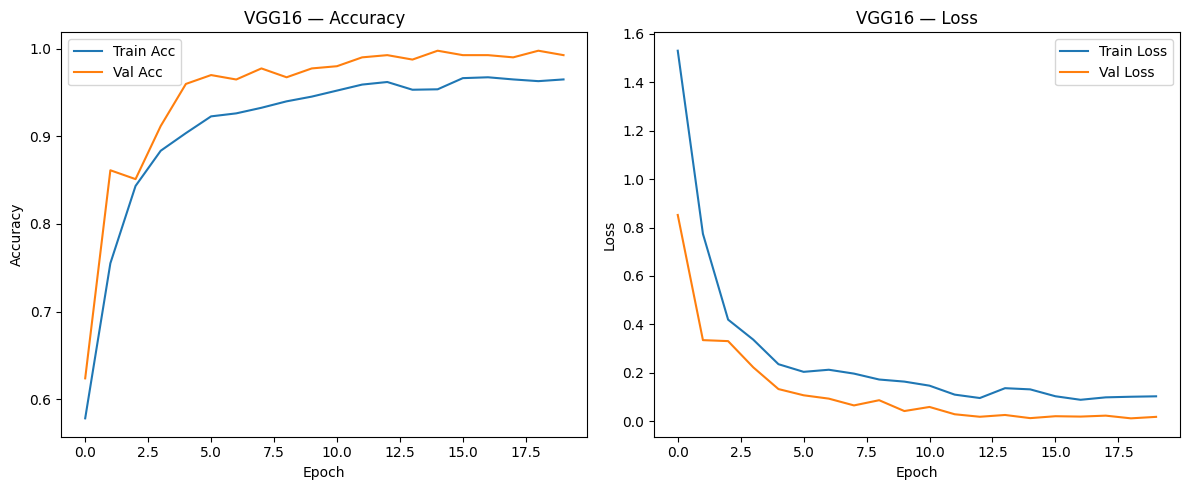

In [11]:
# ── VGG16: Training Graphs ──
plot_training_history(history, "VGG16")

Evaluating VGG16 model...
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 375ms/step

  VGG16 — Evaluation Results


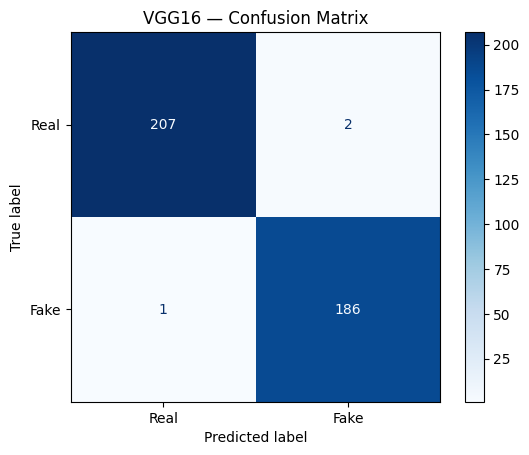

              precision    recall  f1-score   support

        Real       1.00      0.99      0.99       209
        Fake       0.99      0.99      0.99       187

    accuracy                           0.99       396
   macro avg       0.99      0.99      0.99       396
weighted avg       0.99      0.99      0.99       396



In [12]:
# ── VGG16: Evaluation ──
print("Evaluating VGG16 model...")
y_pred = (model.predict(X_test) > 0.5).astype(int)
evaluate_and_plot("VGG16", y_test, y_pred)

---
# 7. Model 2: CNN (From Scratch)

**Architecture:**
- Conv2D(32) → MaxPool → Conv2D(64) → MaxPool → Conv2D(128) → MaxPool
- Flatten → Dense(128, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

**Hyperparameters:**
- Optimizer: Adam (lr=1e-4)
- Loss: Binary Crossentropy
- Epochs: 20, Batch Size: 32

In [13]:
# ── CNN Model Architecture ──
print("Building CNN model...")

cnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("CNN model built and compiled")
cnn_model.summary()

Building CNN model...
CNN model built and compiled


/opt/anaconda3/envs/deepfake_gpu/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# ── CNN Training ──
print("Training CNN model...")

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

print("\nCNN training completed!")

Training CNN model...
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - accuracy: 0.5169 - loss: 0.7116 - val_accuracy: 0.5278 - val_loss: 0.6777
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.5924 - loss: 0.6759 - val_accuracy: 0.6717 - val_loss: 0.6430
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.6139 - loss: 0.6626 - val_accuracy: 0.6591 - val_loss: 0.6215
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - accuracy: 0.6173 - loss: 0.6533 - val_accuracy: 0.6818 - val_loss: 0.6077
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.6428 - loss: 0.6340 - val_accuracy: 0.6894 - val_loss: 0.5915
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.6463 - loss: 0.6240 - val_accuracy: 0.6894 - val_loss: 0.5866
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.6575 - loss: 0.6140 - val_accuracy: 0.7172 - val_loss: 0.5825
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - accuracy: 0.6703 - loss: 0.

In [15]:
# ── CNN: Save Model ──
cnn_model.save(os.path.join(BASE_PATH, "..", "model2_cnn.keras"))
print("CNN model saved")

CNN model saved


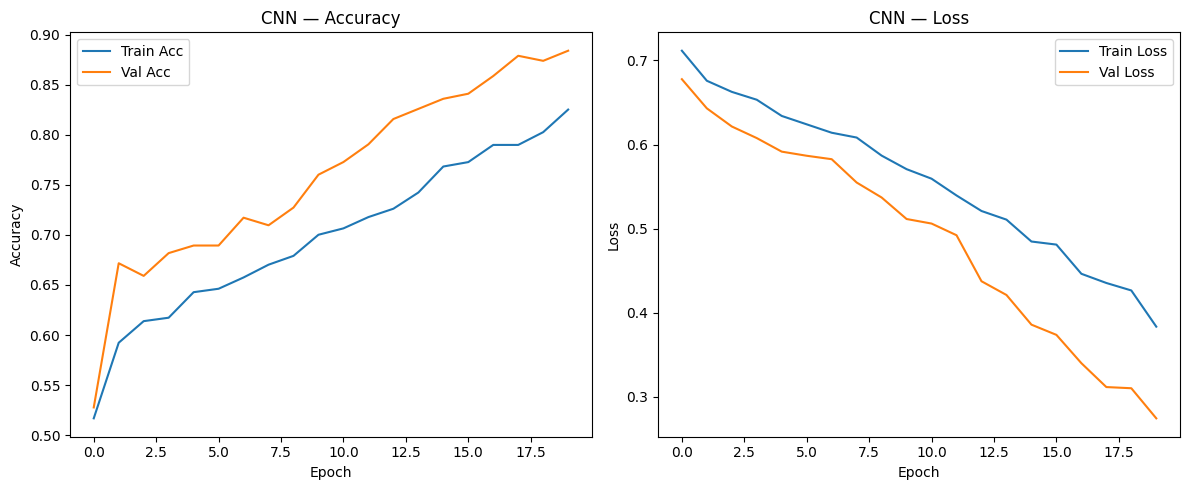

In [16]:
# ── CNN: Training Graphs ──
plot_training_history(history_cnn, "CNN")

Evaluating CNN model...
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

  CNN — Evaluation Results


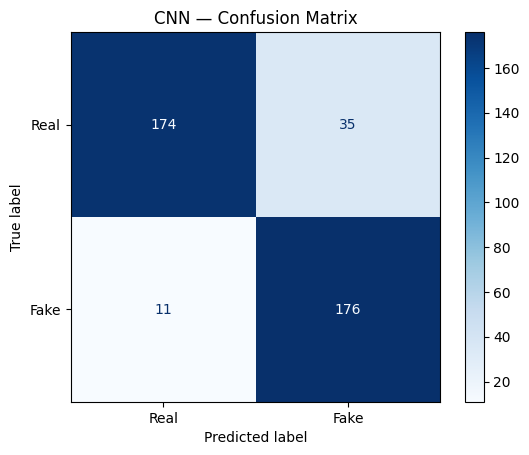

              precision    recall  f1-score   support

        Real       0.94      0.83      0.88       209
        Fake       0.83      0.94      0.88       187

    accuracy                           0.88       396
   macro avg       0.89      0.89      0.88       396
weighted avg       0.89      0.88      0.88       396



In [17]:
# ── CNN: Evaluation ──
print("Evaluating CNN model...")
y_pred_cnn = (cnn_model.predict(X_test) > 0.5).astype(int)
evaluate_and_plot("CNN", y_test, y_pred_cnn)

---
# 8. Model 3: LSTM

**Architecture:**
- Input reshaped to `(IMG_SIZE, IMG_SIZE * 3)` — treating rows as time steps
- LSTM(64) → Dense(32, ReLU) → Dense(1, Sigmoid)

**Hyperparameters:**
- Optimizer: Adam (default lr)
- Loss: Binary Crossentropy
- Epochs: 10, Batch Size: 32

In [18]:
# ── LSTM: Reshape input ──
# Reshape images: treat each row of pixels as a time step
X_train_lstm = X_train.reshape(X_train.shape[0], IMG_SIZE, IMG_SIZE * 3)
X_test_lstm = X_test.reshape(X_test.shape[0], IMG_SIZE, IMG_SIZE * 3)

print(f"LSTM input shape: {X_train_lstm.shape}")

LSTM input shape: (2041, 224, 672)


In [19]:
# ── LSTM Model Architecture ──
print("Building LSTM model...")

lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(IMG_SIZE, IMG_SIZE * 3)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("LSTM model built and compiled")
lstm_model.summary()

Building LSTM model...
LSTM model built and compiled


/opt/anaconda3/envs/deepfake_gpu/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │       188,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 190,785 (745.25 KB)

 Trainable params: 190,785 (745.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ── LSTM Training ──
print("Training LSTM model...")

history_lstm = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_test_lstm, y_test),
    epochs=10,
    batch_size=32
)

print("\nLSTM training completed!")

Training LSTM model...
Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.4993 - loss: 0.7050 - val_accuracy: 0.5278 - val_loss: 0.6891
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5198 - loss: 0.6924 - val_accuracy: 0.5278 - val_loss: 0.6879
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5267 - loss: 0.6918 - val_accuracy: 0.5202 - val_loss: 0.6866
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5282 - loss: 0.6934 - val_accuracy: 0.5278 - val_loss: 0.6848
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5282 - loss: 0.6877 - val_accuracy: 0.5556 - val_loss: 0.6792
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5399 - loss: 0.6848 - val_accuracy: 0.5707 - val_loss: 0.6799
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5551 - loss: 0.6826 - val_accuracy: 0.5631 - val_loss: 0.6786
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5277 - loss: 0.6896 - v

In [21]:
# ── LSTM: Save Model ──
lstm_model.save(os.path.join(BASE_PATH, "..", "model3_lstm.keras"))
print("LSTM model saved")

LSTM model saved


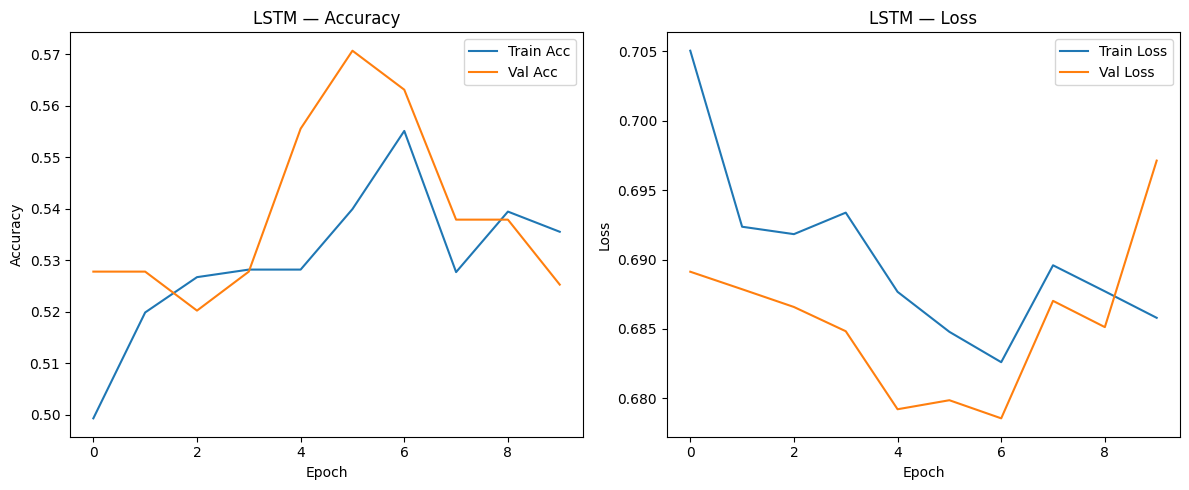

In [22]:
# ── LSTM: Training Graphs ──
plot_training_history(history_lstm, "LSTM")

Evaluating LSTM model...
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

  LSTM — Evaluation Results


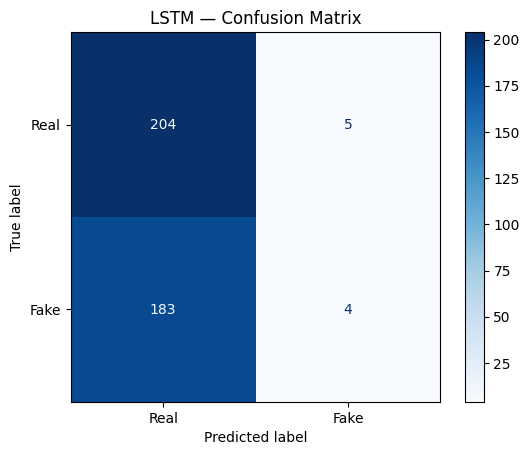

              precision    recall  f1-score   support

        Real       0.53      0.98      0.68       209
        Fake       0.44      0.02      0.04       187

    accuracy                           0.53       396
   macro avg       0.49      0.50      0.36       396
weighted avg       0.49      0.53      0.38       396



In [23]:
# ── LSTM: Evaluation ──
print("Evaluating LSTM model...")
y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int)
evaluate_and_plot("LSTM", y_test, y_pred_lstm)

---
# 10. Model 4: CNN + LSTM Hybrid

**Architecture:**
- CNN feature extraction: Conv2D(32) → Pool → Conv2D(64) → Pool → Conv2D(128) → Pool
- Flatten → Reshape to (128, features) → LSTM(64)
- Dense(64, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

**Hyperparameters:**
- Optimizer: Adam (default lr)
- Loss: Binary Crossentropy
- Epochs: 20, Batch Size: 32

In [24]:
# ── CNN+LSTM Hybrid Model Architecture ──
print("Building CNN+LSTM hybrid model...")

input_layer = Input(shape=(224, 224, 3))

# CNN Part
x = Conv2D(32, (3,3), activation='relu')(input_layer)
x = MaxPooling2D(2,2)(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D(2,2)(x)

x = Conv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D(2,2)(x)

# Flatten and reshape for LSTM
x = Flatten()(x)
x = Reshape((128, -1))(x)   # (timesteps, features)

# LSTM Part
x = LSTM(64)(x)

# Dense classifier
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

cnn_lstm_model = Model(inputs=input_layer, outputs=output)

cnn_lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("CNN+LSTM model built and compiled")
cnn_lstm_model.summary()

Building CNN+LSTM hybrid model...
CNN+LSTM model built and compiled


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 128, 676)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │       189,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 287,169 (1.10 MB)

 Trainable params: 287,169 (1.10 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# ── CNN+LSTM Training ──
print("Training CNN+LSTM model...")

history_cnn_lstm = cnn_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

print("\nCNN+LSTM training completed!")

Training CNN+LSTM model...
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - accuracy: 0.4968 - loss: 0.6960 - val_accuracy: 0.5278 - val_loss: 0.6918
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.5292 - loss: 0.6918 - val_accuracy: 0.5278 - val_loss: 0.6916
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.5296 - loss: 0.6922 - val_accuracy: 0.5278 - val_loss: 0.6916
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.5100 - loss: 0.6924 - val_accuracy: 0.5278 - val_loss: 0.6913
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.5282 - loss: 0.6912 - val_accuracy: 0.5278 - val_loss: 0.6915
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.5262 - loss: 0.7026 - val_accuracy: 0.5000 - val_loss: 0.6948
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.5110 - loss: 0.6991 - val_accuracy: 0.5278 - val_loss: 0.6913
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.5189 - los

In [26]:
# ── CNN+LSTM: Save Model ──
cnn_lstm_model.save(os.path.join(BASE_PATH, "..", "cnn_lstm_model.keras"))
print("CNN+LSTM model saved")

CNN+LSTM model saved


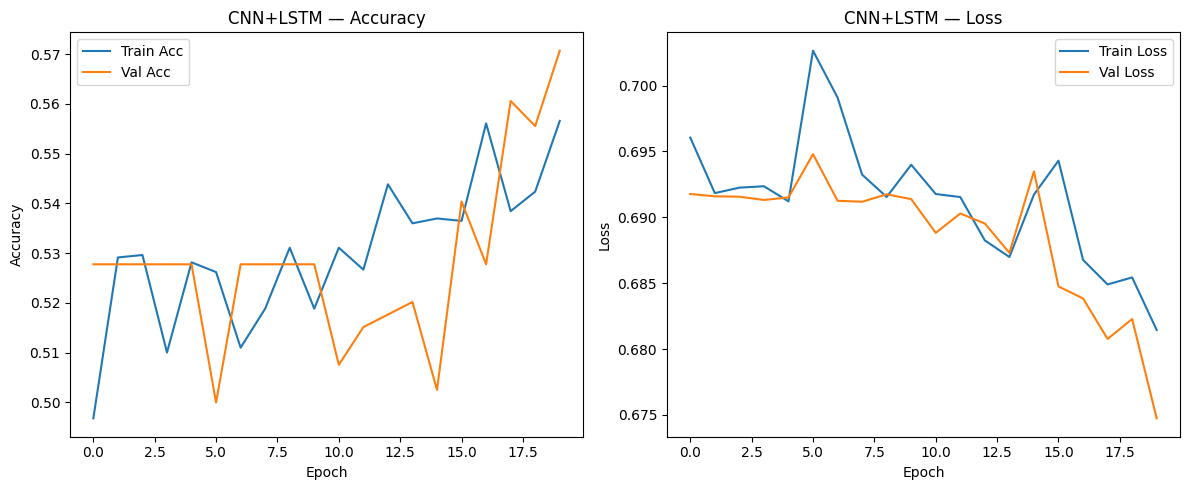

In [27]:
# ── CNN+LSTM: Training Graphs ──
plot_training_history(history_cnn_lstm, "CNN+LSTM")

Evaluating CNN+LSTM model...


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step

  CNN+LSTM — Evaluation Results


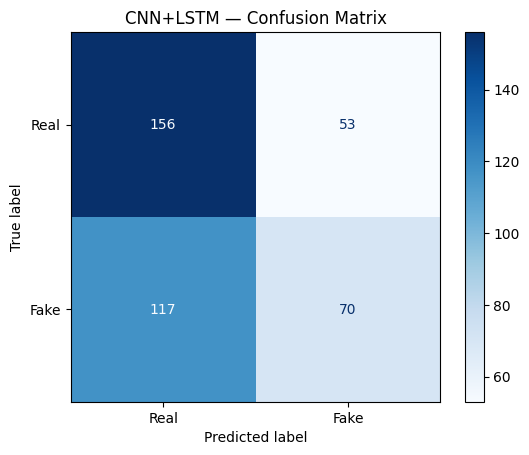

              precision    recall  f1-score   support

        Real       0.57      0.75      0.65       209
        Fake       0.57      0.37      0.45       187

    accuracy                           0.57       396
   macro avg       0.57      0.56      0.55       396
weighted avg       0.57      0.57      0.55       396



In [28]:
# ── CNN+LSTM: Evaluation ──
print("Evaluating CNN+LSTM model...")
y_pred_hybrid = (cnn_lstm_model.predict(X_test) > 0.5).astype(int)
evaluate_and_plot("CNN+LSTM", y_test, y_pred_hybrid)

---
# 11. Model 5: InceptionV3 (Transfer Learning)

**Architecture:**
- Pre-trained InceptionV3 backbone (ImageNet weights)
- Top 50 layers unfrozen for fine-tuning
- GlobalAveragePooling2D → Dense(128, ReLU) → Dropout(0.5) → Dense(64, ReLU) → Dense(1, Sigmoid)

**Hyperparameters:**
- Optimizer: Adam (lr=1e-5)
- Loss: Binary Crossentropy
- Epochs: 20, Batch Size: 32

In [29]:
# ── InceptionV3 Model Architecture ──
print("Building InceptionV3 model...")

base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze early layers, unfreeze last 50 for fine-tuning
for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

inception_model = Model(inputs=base_model.input, outputs=output)

inception_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("InceptionV3 model built and compiled")

Building InceptionV3 model...
InceptionV3 model built and compiled


In [30]:
# ── InceptionV3 Training ──
print("Training InceptionV3 model...")

history_inception = inception_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

print("\nInceptionV3 training completed!")

Training InceptionV3 model...
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 371ms/step - accuracy: 0.5120 - loss: 0.7695 - val_accuracy: 0.5556 - val_loss: 0.6870
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.5532 - loss: 0.7267 - val_accuracy: 0.6338 - val_loss: 0.6439
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 270ms/step - accuracy: 0.5904 - loss: 0.6955 - val_accuracy: 0.6742 - val_loss: 0.6086
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 291ms/step - accuracy: 0.6002 - loss: 0.6816 - val_accuracy: 0.7121 - val_loss: 0.5797
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 325ms/step - accuracy: 0.6208 - loss: 0.6595 - val_accuracy: 0.7323 - val_loss: 0.5548
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 313ms/step - accuracy: 0.6472 - loss: 0.6297 - val_accuracy: 0.7551 - val_loss: 0.5322
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 299ms/step - accuracy: 0.6556 - loss: 0.6239 - val_accuracy: 0.7702 - val_loss: 0.5070
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 297ms/step - accuracy: 0.

In [31]:
# ── InceptionV3: Save Model ──
inception_model.save(os.path.join(BASE_PATH, "..", "inception_model.keras"))
print("InceptionV3 model saved")

InceptionV3 model saved


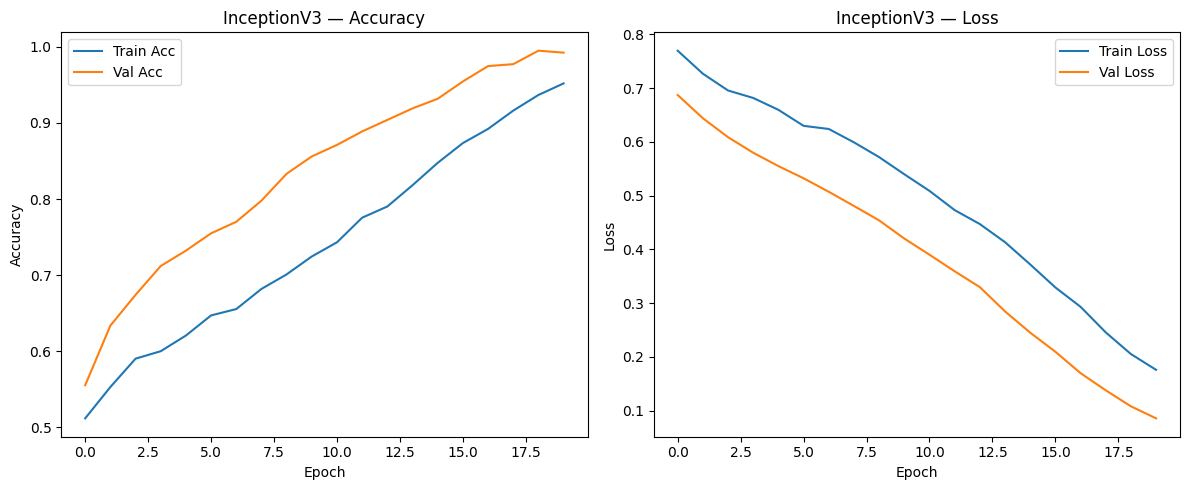

In [32]:
# ── InceptionV3: Training Graphs ──
plot_training_history(history_inception, "InceptionV3")

Evaluating InceptionV3 model...
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 392ms/step

  InceptionV3 — Evaluation Results


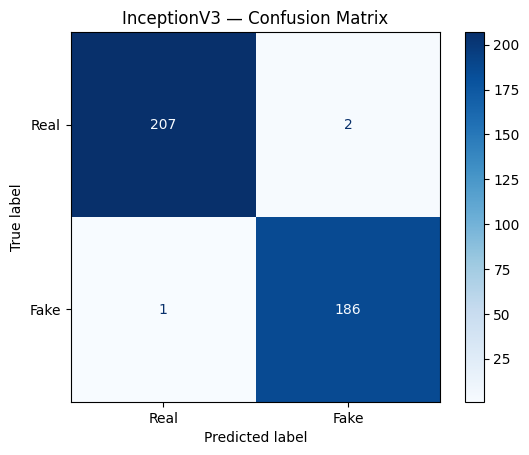

              precision    recall  f1-score   support

        Real       1.00      0.99      0.99       209
        Fake       0.99      0.99      0.99       187

    accuracy                           0.99       396
   macro avg       0.99      0.99      0.99       396
weighted avg       0.99      0.99      0.99       396



In [33]:
# ── InceptionV3: Evaluation ──
print("Evaluating InceptionV3 model...")
y_pred_inception = (inception_model.predict(X_test) > 0.5).astype(int)
evaluate_and_plot("InceptionV3", y_test, y_pred_inception)

---
# 12. Model 6: InceptionV3 + Attention

**Architecture:**
- Pre-trained InceptionV3 backbone (top 50 layers unfrozen)
- GlobalAveragePooling2D → Attention layer (Dense 2048 → sigmoid → multiply)
- Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

The attention mechanism allows the model to focus on the most discriminative features.

**Hyperparameters:**
- Optimizer: Adam (lr=1e-5)
- Loss: Binary Crossentropy
- Epochs: 20, Batch Size: 32

In [34]:
# ── InceptionV3 + Attention Model Architecture ──
print("Building InceptionV3 + Attention model...")

# Reload InceptionV3 base for the attention model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)   # shape = (2048,)

# Attention layer with matching dimension
attention = Dense(2048, activation='relu')(x)
attention = Dense(2048, activation='sigmoid')(attention)

# Apply attention
x = Multiply()([x, attention])

# Classification head
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_attention = Model(inputs=base_model.input, outputs=output)

# Freeze + partial unfreeze
for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

model_attention.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("InceptionV3 + Attention model built and compiled")

Building InceptionV3 + Attention model...
InceptionV3 + Attention model built and compiled


In [35]:
# ── Attention Model Training ──
print("Training InceptionV3 + Attention model...")

history_attention = model_attention.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32
)

print("\nAttention model training completed!")

Training InceptionV3 + Attention model...
Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 470ms/step - accuracy: 0.5149 - loss: 0.7071 - val_accuracy: 0.6136 - val_loss: 0.6624
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 278ms/step - accuracy: 0.5977 - loss: 0.6712 - val_accuracy: 0.7121 - val_loss: 0.6183
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 277ms/step - accuracy: 0.6242 - loss: 0.6404 - val_accuracy: 0.7677 - val_loss: 0.5757
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 18s 286ms/step - accuracy: 0.6649 - loss: 0.6095 - val_accuracy: 0.7904 - val_loss: 0.5338
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 316ms/step - accuracy: 0.7026 - loss: 0.5767 - val_accuracy: 0.8207 - val_loss: 0.4794
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 326ms/step - accuracy: 0.7501 - loss: 0.5243 - val_accuracy: 0.8258 - val_loss: 0.4358
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 315ms/step - accuracy: 0.7888 - loss: 0.4786 - val_accuracy: 0.8712 - val_loss: 0.3663
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 306ms/step - 

In [36]:
# ── Attention: Save Model ──
model_attention.save(os.path.join(BASE_PATH, "..", "inception_attention_model.keras"))
print("Attention model saved")

Attention model saved


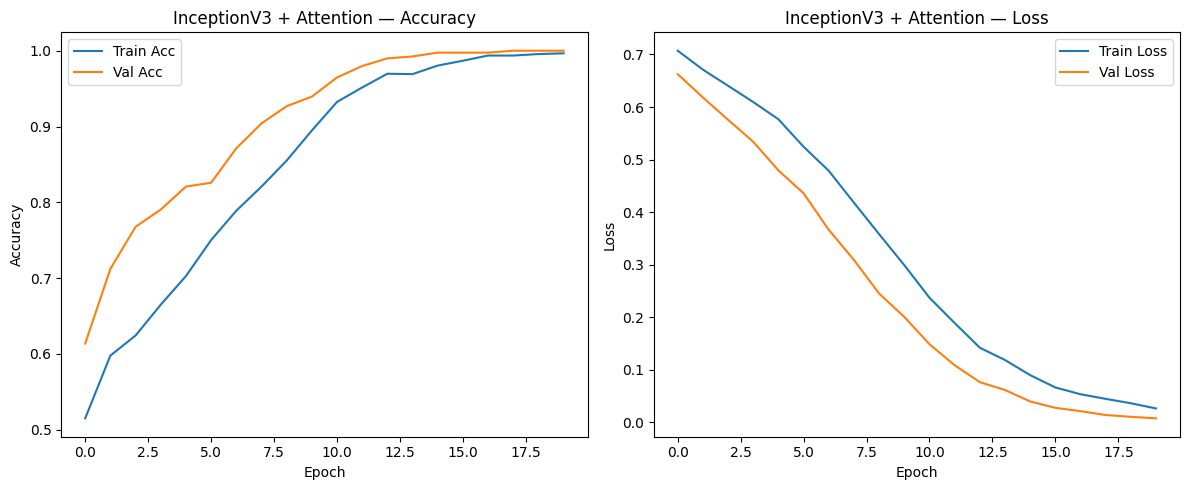

In [37]:
# ── Attention: Training Graphs ──
plot_training_history(history_attention, "InceptionV3 + Attention")

Evaluating InceptionV3 + Attention model...


13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 416ms/step

  InceptionV3 + Attention — Evaluation Results


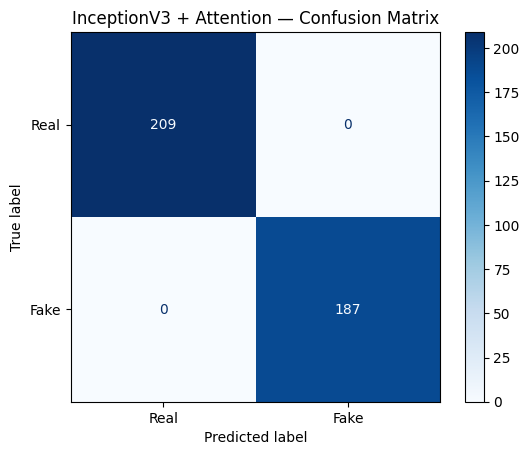

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       209
        Fake       1.00      1.00      1.00       187

    accuracy                           1.00       396
   macro avg       1.00      1.00      1.00       396
weighted avg       1.00      1.00      1.00       396



In [38]:
# ── Attention: Evaluation ──
print("Evaluating InceptionV3 + Attention model...")
y_pred_att = (model_attention.predict(X_test) > 0.5).astype(int)
evaluate_and_plot("InceptionV3 + Attention", y_test, y_pred_att)

---
# 13. Final Model Comparison

Compare all trained models side-by-side using test accuracy, confusion matrices, and a bar chart.

In [39]:
# ── Compute test accuracies for all models ──
print("Computing final accuracies...\n")

# Reshape for LSTM evaluation
X_test_lstm_eval = X_test.reshape(X_test.shape[0], -1, 3)
lstm_model.predict(X_test_lstm_eval[:1])  # build fix

acc_vgg       = model.evaluate(X_test, y_test, verbose=0)[1]
acc_cnn       = cnn_model.evaluate(X_test, y_test, verbose=0)[1]
acc_lstm      = lstm_model.evaluate(X_test_lstm_eval, y_test, verbose=0)[1]
acc_cnn_lstm  = cnn_lstm_model.evaluate(X_test, y_test, verbose=0)[1]
acc_inception = inception_model.evaluate(X_test, y_test, verbose=0)[1]
acc_attention = model_attention.evaluate(X_test, y_test, verbose=0)[1]

# Build comparison table
data = {
    "Model": ["VGG16+MTCNN", "CNN", "LSTM", "CNN+LSTM", "CNN+InceptionV3", "CNN+InceptionV3+Attention"],
    "Accuracy": [acc_vgg, acc_cnn, acc_lstm, acc_cnn_lstm, acc_inception, acc_attention]
}

df = pd.DataFrame(data)
df = df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n" + "="*50)
print("  📊 Model Comparison — Test Accuracy")
print("="*50)
print(df.to_string(index=False))

Computing final accuracies...

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step

  📊 Model Comparison — Test Accuracy
                    Model  Accuracy
CNN+InceptionV3+Attention  1.000000
              VGG16+MTCNN  0.992424
          CNN+InceptionV3  0.992424
                      CNN  0.883838
                 CNN+LSTM  0.570707
                     LSTM  0.532828


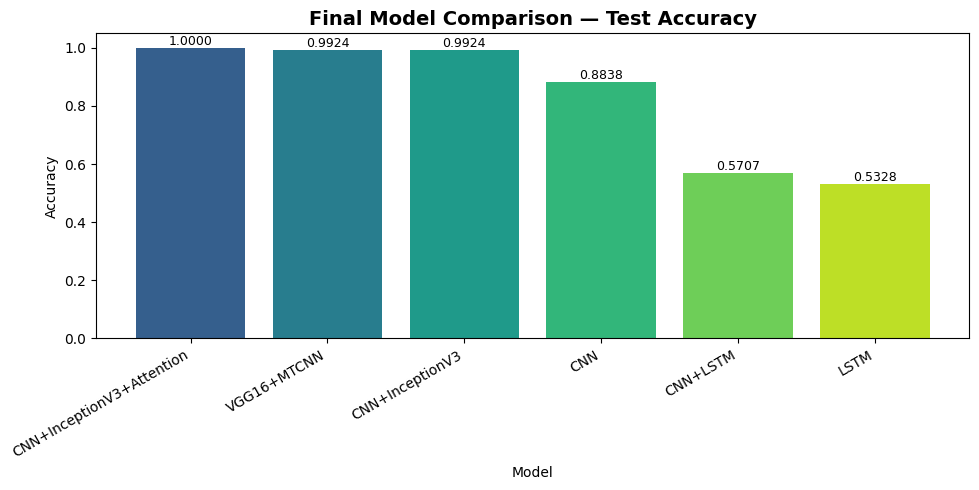

In [40]:
# ── Comparison Bar Chart ──
plt.figure(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(df)))
plt.bar(df["Model"], df["Accuracy"], color=colors)
plt.title("Final Model Comparison — Test Accuracy", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.05)
for i, v in enumerate(df["Accuracy"]):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


📋 Detailed Evaluation for All Models:




  VGG16 — Evaluation Results


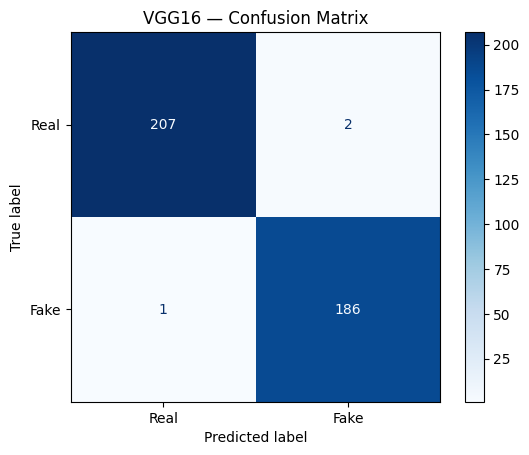

              precision    recall  f1-score   support

        Real       1.00      0.99      0.99       209
        Fake       0.99      0.99      0.99       187

    accuracy                           0.99       396
   macro avg       0.99      0.99      0.99       396
weighted avg       0.99      0.99      0.99       396


  CNN — Evaluation Results


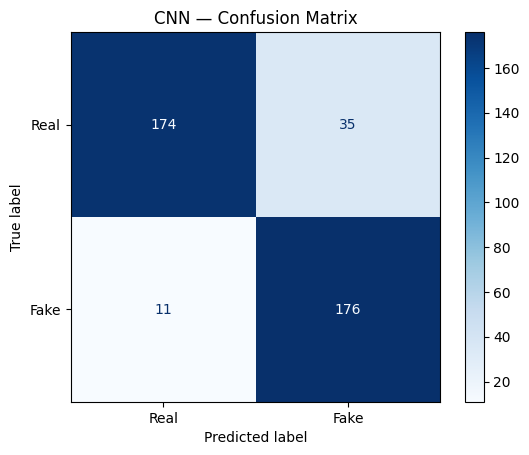

              precision    recall  f1-score   support

        Real       0.94      0.83      0.88       209
        Fake       0.83      0.94      0.88       187

    accuracy                           0.88       396
   macro avg       0.89      0.89      0.88       396
weighted avg       0.89      0.88      0.88       396


  LSTM — Evaluation Results


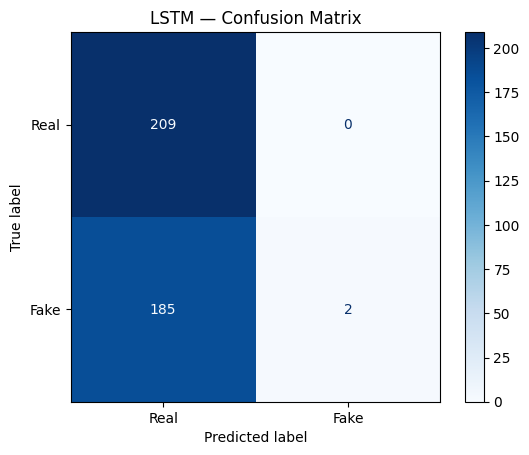

              precision    recall  f1-score   support

        Real       0.53      1.00      0.69       209
        Fake       1.00      0.01      0.02       187

    accuracy                           0.53       396
   macro avg       0.77      0.51      0.36       396
weighted avg       0.75      0.53      0.38       396


  CNN+LSTM — Evaluation Results


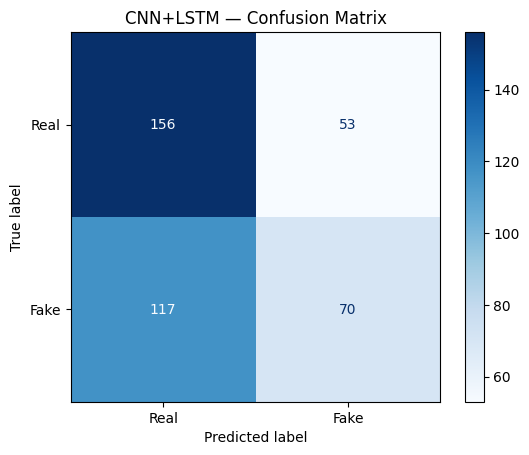

              precision    recall  f1-score   support

        Real       0.57      0.75      0.65       209
        Fake       0.57      0.37      0.45       187

    accuracy                           0.57       396
   macro avg       0.57      0.56      0.55       396
weighted avg       0.57      0.57      0.55       396


  InceptionV3 — Evaluation Results


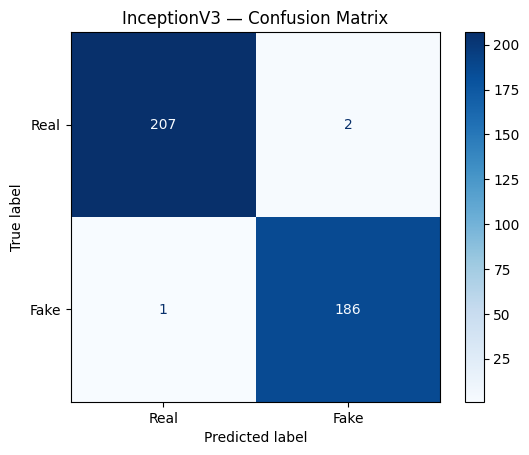

              precision    recall  f1-score   support

        Real       1.00      0.99      0.99       209
        Fake       0.99      0.99      0.99       187

    accuracy                           0.99       396
   macro avg       0.99      0.99      0.99       396
weighted avg       0.99      0.99      0.99       396


  InceptionV3+Attention — Evaluation Results


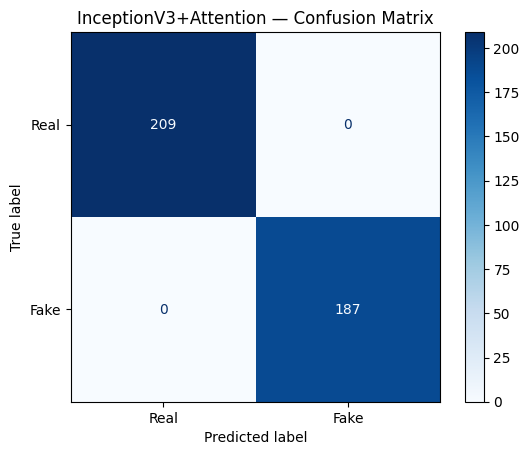

              precision    recall  f1-score   support

        Real       1.00      1.00      1.00       209
        Fake       1.00      1.00      1.00       187

    accuracy                           1.00       396
   macro avg       1.00      1.00      1.00       396
weighted avg       1.00      1.00      1.00       396



In [41]:
# ── Individual Confusion Matrices for All Models ──
print("\n📋 Detailed Evaluation for All Models:\n")

# Reshape for LSTM
X_test_lstm_cm = X_test.reshape(X_test.shape[0], -1, 3)

y_pred_vgg_cm       = (model.predict(X_test, verbose=0) > 0.5).astype(int)
y_pred_cnn_cm       = (cnn_model.predict(X_test, verbose=0) > 0.5).astype(int)
y_pred_lstm_cm      = (lstm_model.predict(X_test_lstm_cm, verbose=0) > 0.5).astype(int)
y_pred_cnn_lstm_cm  = (cnn_lstm_model.predict(X_test, verbose=0) > 0.5).astype(int)
y_pred_inception_cm = (inception_model.predict(X_test, verbose=0) > 0.5).astype(int)
y_pred_attention_cm = (model_attention.predict(X_test, verbose=0) > 0.5).astype(int)

evaluate_and_plot("VGG16", y_test, y_pred_vgg_cm)
evaluate_and_plot("CNN", y_test, y_pred_cnn_cm)
evaluate_and_plot("LSTM", y_test, y_pred_lstm_cm)
evaluate_and_plot("CNN+LSTM", y_test, y_pred_cnn_lstm_cm)
evaluate_and_plot("InceptionV3", y_test, y_pred_inception_cm)
evaluate_and_plot("InceptionV3+Attention", y_test, y_pred_attention_cm)

---
# 14. Conclusion

This project focused on detecting AI-generated (fake) and real images using multiple deep learning architectures, including CNN, VGG16, LSTM, hybrid CNN+LSTM, CNN+Inception, and CNN+Inception with Attention.

The experimental results show that traditional CNN and VGG16 models provide strong baseline performance due to their ability to extract spatial features effectively. However, the LSTM model performed comparatively lower, indicating that sequential modeling alone is less effective for static image classification tasks.

The hybrid CNN+LSTM model demonstrated moderate improvement by combining spatial and sequential learning, but still did not outperform advanced architectures. The CNN+Inception model significantly improved accuracy by leveraging multi-scale feature extraction, allowing the model to capture both fine and coarse patterns in images.

The best performance was achieved by the **CNN+Inception+Attention** model. The addition of the attention mechanism enabled the model to focus on the most relevant regions of the image, improving classification accuracy and interpretability. This makes the model particularly effective for deepfake detection, where subtle artifacts need to be identified.

Overall, the study concludes that combining deep convolutional architectures with attention mechanisms leads to superior performance in detecting AI-generated media. The results highlight the importance of feature extraction depth and selective focus in building robust deepfake detection systems.